# Мониторинг ML-сервиса

Проект: сервис автоматической классификации обращений клиентов банка в службу поддержки.

Сервис получает текст обращения пользователя и определяет одну из 8 категорий:

- `PAYMENT_OUT_FAIL`
- `INCOMING_DELAY`
- `APP_LOGIN`
- `APP_TECH`
- `FRAUD_SUSPECTED`
- `CARD_ISSUE`
- `ACCOUNT_SEIZED`
- `KYC_VERIFICATION`

Мониторинг нужен для того, чтобы после запуска сервиса отслеживать:

- доступность и стабильность API;
- скорость обработки запросов;
- ошибки сервиса;
- поведение модели;
- изменения входных данных;
- возможный drift данных или модели.

Мониторинг не заменяет оценку качества модели на тестовой выборке.  
Тестовая выборка показывает качество модели до запуска, а мониторинг нужен для контроля её работы после запуска.

## План мониторинга

Мониторинг проекта разделён на четыре группы:

1. Технические метрики сервиса.
2. Метрики поведения модели.
3. Метрики входных данных.
4. Контроль drift и алерты.

Для каждой группы определяются:

- что измеряется;
- зачем это нужно;
- какое отклонение считается проблемой;
- какие действия нужно выполнить при возникновении проблемы.

## 1. Технические метрики сервиса

Технический мониторинг показывает, насколько стабильно и быстро работает API.

| Метрика | Что показывает | Зачем отслеживать |
|---|---|---|
| Количество запросов | Сколько запросов получает сервис за определённый период | Позволяет видеть нагрузку и резкие изменения количества обращений |
| Время ответа API | Сколько времени сервис тратит на обработку запроса | Помогает заметить замедление сервиса |
| Доля HTTP-ошибок | Какая часть запросов завершилась ошибкой | Позволяет быстро обнаружить проблемы в работе API |
| Статус сервиса | Доступен ли API и загружена ли модель | Позволяет определить, работает ли сервис в данный момент |

### Алерты технического мониторинга

| Условие | Почему это проблема | Действие |
|---|---|---|
| Доля ошибок API > 5% за 10 минут | Большое количество запросов завершается ошибкой | Проверить логи сервиса и причины ошибок |
| Среднее время ответа > 1 секунды | Сервис работает заметно медленнее обычного | Проверить нагрузку, модель и состояние сервера |
| Сервис не отвечает на `/health` | API может быть недоступен | Проверить запуск приложения |
| Модель не загружена | Сервис не сможет выполнять классификацию | Проверить файл модели и процесс её загрузки |

## 2. Метрики поведения модели

После запуска сервиса важно отслеживать не только работу API, но и поведение самой модели.

Для этого контролируются следующие показатели:

| Метрика | Что показывает | Зачем отслеживать |
|---|---|---|
| Распределение предсказанных классов | Как часто модель выбирает каждую из 8 категорий | Позволяет заметить резкое изменение структуры обращений или поведения модели |
| Уверенность модели | Насколько модель уверена в своём прогнозе | Помогает находить сложные и неоднозначные обращения |
| Доля прогнозов с низкой уверенностью | Как часто модель сомневается в классификации | Может указывать на новые типы обращений или ухудшение качества модели |
| Частота путаницы между похожими классами | Насколько часто возникают проблемы между близкими категориями | Особенно важно для классов `APP_TECH` и `APP_LOGIN` |

### Низкая уверенность модели

Для дополнительного контроля можно считать долю прогнозов, у которых confidence ниже заданного порога.

Для учебного проекта используется порог:

`confidence < 0.60`

Если доля таких прогнозов заметно растёт, это может означать:

- появление новых формулировок обращений;
- неоднозначные запросы;
- изменение входных данных;
- возможное ухудшение работы модели.

### Контроль похожих классов

На этапе baseline основной источник ошибок был связан с классами:

- `APP_TECH`
- `APP_LOGIN`

Часть обращений класса `APP_TECH` модель ошибочно относила к `APP_LOGIN`.

Поэтому после запуска сервиса отдельно контролируется доля прогнозов этих двух классов.

Резкое изменение их соотношения может быть признаком:

- изменения структуры обращений;
- появления новых формулировок;
- ухудшения разделения похожих классов.

### Алерты для поведения модели

| Условие | Почему это проблема | Действие |
|---|---|---|
| Доля прогнозов с confidence < 0.60 превышает 30% | Модель часто не уверена в результате | Проверить новые входные данные и примеры с низкой уверенностью |
| Доля одного класса резко изменилась относительно обычного уровня | Возможно изменение данных или поведения модели | Проверить распределение входных обращений |
| Сильно изменилось соотношение `APP_TECH` и `APP_LOGIN` | Возможна проблема с разделением похожих классов | Провести ручную проверку части обращений |

## 3. Мониторинг входных данных

Модель обучалась на определённом наборе текстовых обращений. После запуска сервиса реальные обращения пользователей могут постепенно изменяться.

Поэтому необходимо отслеживать характеристики входных данных и сравнивать их с данными, на которых обучалась модель.

Для проекта контролируются следующие показатели:

| Метрика | Что показывает | Зачем отслеживать |
|---|---|---|
| Средняя длина текста | Средний размер обращений пользователей | Позволяет заметить изменение формата запросов |
| Распределение длины текстов | Как часто встречаются короткие и длинные обращения | Помогает обнаружить существенное изменение структуры текстов |
| Доля очень коротких или длинных текстов | Количество необычных по размеру запросов | Может указывать на новые сценарии использования или некорректные данные |
| Доля пустых или некорректных текстов | Качество входных данных | Позволяет обнаружить ошибки интеграции или пользовательского ввода |
| Распределение предсказанных классов | Частота каждой категории | Может указывать на изменение структуры обращений |

## 4. Data Drift

Data drift — это изменение распределения входных данных по сравнению с данными, на которых обучалась модель.

Например, модель могла обучаться в основном на коротких обращениях:

`"Не могу войти в приложение"`

а после запуска пользователи начали отправлять длинные сообщения с подробным описанием проблемы.

Само наличие drift не означает, что модель обязательно стала работать плохо. Оно показывает, что реальные данные изменились и качество модели необходимо дополнительно проверить.

### Data drift и качество модели

Data drift и снижение качества модели — разные понятия.

**Data drift** означает, что изменились входные данные.

**Снижение качества модели** означает, что модель стала чаще ошибаться.

Если после запуска известны реальные правильные категории обращений, можно дополнительно рассчитывать Accuracy, Precision, Recall и F1 на новых данных.

Если правильные ответы становятся известны не сразу, сначала используются косвенные признаки:

- изменение входных данных;
- изменение распределения классов;
- снижение confidence;
- рост количества прогнозов с низкой уверенностью.

### Признаки возможного drift

Для проекта используются несколько простых признаков возможного изменения данных:

1. Средняя длина новых обращений заметно отличается от обучающей выборки.
2. Увеличивается доля очень коротких или очень длинных текстов.
3. Существенно меняется распределение предсказанных классов.
4. Увеличивается доля прогнозов с низким confidence.
5. Меняется соотношение похожих классов `APP_TECH` и `APP_LOGIN`.

При обнаружении таких изменений необходимо проверить новые обращения вручную и при необходимости оценить модель на свежей размеченной выборке.

### Алерты для данных и drift

| Условие | Возможная причина | Действие |
|---|---|---|
| Средняя длина текста изменилась более чем на 50% относительно обучающих данных | Изменился формат обращений пользователей | Проверить выборку новых текстов |
| Более 20% обращений имеют необычную длину | В систему поступают данные другого типа | Проверить источник данных и примеры запросов |
| Доля прогнозов с низким confidence превышает 30% | Новые данные плохо похожи на обучающие | Провести ручной анализ обращений |
| Распределение классов существенно изменилось | Изменилась структура обращений или поведение модели | Сравнить новые данные с обучающей выборкой |

In [1]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd

train_df = pd.read_csv('train.csv')

print(train_df.shape)
print(train_df.columns.tolist())
train_df.head()

(764, 2)
['text', 'label']


,text,label
0,адрес подтверждения не приняли квитанция читае...,KYC_VERIFICATION
1,"Слишком много попыток, блок на сутки. Можно ли...",APP_LOGIN
2,СМС с кодом входа приходит с задержкой 10–15 м...,APP_LOGIN
3,SEPA перевод CHF отправлен банк говорит ждите ...,INCOMING_DELAY
4,возврат авиабилета обещали до 7 дней прошло 9 ...,INCOMING_DELAY


## 5. Базовые значения для мониторинга

Для обнаружения изменений во входных данных необходимо знать, как выглядели данные в момент обучения модели.

В качестве эталонной выборки используется `train.csv`.

Для неё рассчитываются:

- количество обращений;
- средняя и медианная длина текста;
- минимальная и максимальная длина;
- 5-й и 95-й процентили длины;
- распределение классов.

Эти значения будут использоваться как reference для сравнения с новыми данными после запуска сервиса.

In [3]:
train_df['text_length'] = train_df['text'].str.split().str.len()

train_df[['text', 'text_length']].head()

,text,text_length
0,адрес подтверждения не приняли квитанция читае...,7
1,"Слишком много попыток, блок на сутки. Можно ли...",10
2,СМС с кодом входа приходит с задержкой 10–15 м...,14
3,SEPA перевод CHF отправлен банк говорит ждите ...,10
4,возврат авиабилета обещали до 7 дней прошло 9 ...,10


In [4]:
reference_length = pd.DataFrame({
    'Метрика': [
        'Количество обращений',
        'Средняя длина',
        'Медиана',
        'Минимальная длина',
        'Максимальная длина',
        '5-й процентиль',
        '95-й процентиль'
    ],
    'Значение': [
        len(train_df),
        round(train_df['text_length'].mean(), 2),
        round(train_df['text_length'].median(), 2),
        train_df['text_length'].min(),
        train_df['text_length'].max(),
        round(train_df['text_length'].quantile(0.05), 2),
        round(train_df['text_length'].quantile(0.95), 2)
    ]
})

reference_length

,Метрика,Значение
0,Количество обращений,764.00
1,Средняя длина,8.98
2,Медиана,9.00
3,Минимальная длина,5.00
4,Максимальная длина,18.00
5,5-й процентиль,6.00
6,95-й процентиль,12.00


### Распределение классов

Также сохраняется распределение категорий в обучающей выборке.

После запуска сервиса его можно сравнивать с распределением предсказаний модели на новых данных.

Сильное изменение распределения само по себе не означает ошибку модели, но является поводом проверить новые данные.

In [5]:
class_distribution = (
    train_df['label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_reference = pd.DataFrame({
    'Класс': class_distribution.index,
    'Доля, %': class_distribution.values
})

class_reference

,Класс,"Доля, %"
0,APP_LOGIN,13.74
1,PAYMENT_OUT_FAIL,13.48
2,INCOMING_DELAY,13.35
3,CARD_ISSUE,12.96
4,ACCOUNT_SEIZED,12.83
5,FRAUD_SUSPECTED,12.04
6,KYC_VERIFICATION,11.91
7,APP_TECH,9.69


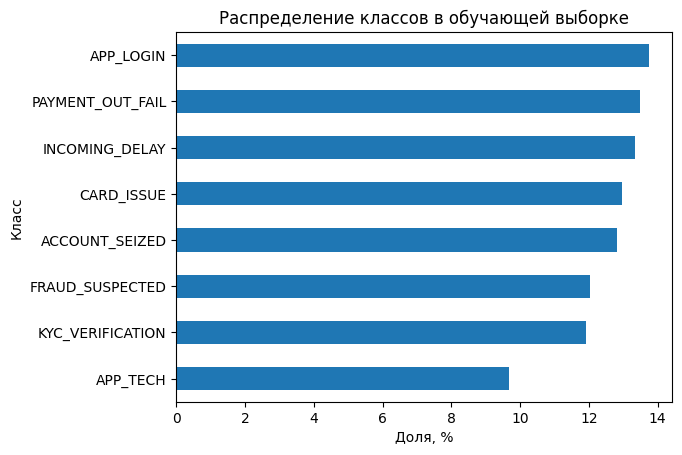

In [7]:
import matplotlib.pyplot as plt

class_distribution.sort_values().plot(kind='barh')

plt.xlabel('Доля, %')
plt.ylabel('Класс')
plt.title('Распределение классов в обучающей выборке')
plt.show()

### Вывод по базовым значениям

В обучающей выборке находится 764 обращения.

Средняя длина обращения составляет 8.98 слова, медианная — 9 слов.  
5-й и 95-й процентили равны 6 и 12 словам соответственно.

Поэтому для мониторинга тексты короче 6 слов или длиннее 12 слов можно считать необычными по длине относительно основной части обучающей выборки.

Распределение классов достаточно равномерное: доля каждого класса составляет примерно от 9.7% до 13.7%.

Полученные значения используются как reference для сравнения с новыми обращениями после запуска сервиса.

## 6. Автоматическая проверка изменений входных данных

На основе обучающей выборки фиксируются reference-значения.

Для новых обращений будут проверяться:

- изменение средней длины текста;
- доля текстов с необычной длиной;
- доля пустых текстов.

Если показатель превышает установленный порог, формируется статус `ALERT`.

In [8]:
reference_mean_length = train_df['text_length'].mean()
reference_low_length = train_df['text_length'].quantile(0.05)
reference_high_length = train_df['text_length'].quantile(0.95)

print('Средняя длина:', round(reference_mean_length, 2))
print('Нижняя граница:', reference_low_length)
print('Верхняя граница:', reference_high_length)

Средняя длина: 8.98
Нижняя граница: 6.0
Верхняя граница: 12.0


In [9]:
def check_input_data(current_df):
    current_df = current_df.copy()

    texts = (
        current_df['text']
        .fillna('')
        .astype(str)
        .str.strip()
    )

    current_df['text_length'] = texts.str.split().str.len()

    current_mean = current_df['text_length'].mean()

    mean_change = abs(
        current_mean - reference_mean_length
    ) / reference_mean_length

    unusual_share = (
        (current_df['text_length'] < reference_low_length) |
        (current_df['text_length'] > reference_high_length)
    ).mean()

    empty_share = (texts == '').mean()

    results = pd.DataFrame({
        'Метрика': [
            'Средняя длина текста',
            'Изменение средней длины',
            'Доля текстов необычной длины',
            'Доля пустых текстов'
        ],
        'Значение': [
            round(current_mean, 2),
            f'{mean_change * 100:.2f}%',
            f'{unusual_share * 100:.2f}%',
            f'{empty_share * 100:.2f}%'
        ],
        'Порог алерта': [
            '-',
            '> 50%',
            '> 20%',
            '> 1%'
        ],
        'Статус': [
            'INFO',
            'ALERT' if mean_change > 0.50 else 'OK',
            'ALERT' if unusual_share > 0.20 else 'OK',
            'ALERT' if empty_share > 0.01 else 'OK'
        ]
    })

    return results

In [10]:
check_input_data(train_df)

,Метрика,Значение,Порог алерта,Статус
0,Средняя длина текста,8.98,-,INFO
1,Изменение средней длины,0.00%,> 50%,OK
2,Доля текстов необычной длины,5.37%,> 20%,OK
3,Доля пустых текстов,0.00%,> 1%,OK


### Проверка на обучающей выборке

Для проверки работы функции в качестве текущих данных была использована сама обучающая выборка.

В этом случае существенного drift ожидаться не должно, так как текущие данные совпадают с reference-данными.

Такая проверка используется только для проверки корректности логики мониторинга.

## 7. Проверка обнаружения drift

Для проверки работы мониторинга создаётся искусственный пример изменённых данных.

В тестовой выборке тексты специально увеличиваются по длине.  
Такой пример имитирует ситуацию, когда после запуска сервиса формат обращений пользователей существенно изменился.

После этого новые данные передаются в функцию мониторинга.

In [11]:
drift_df = train_df[['text', 'label']].sample(
    n=100,
    random_state=42
).copy()

drift_df['text'] = drift_df['text'].apply(
    lambda text: ' '.join([text] * 3)
)

drift_df.head()

,text,label
357,Поступление из маркетплейса обычно в день прод...,INCOMING_DELAY
259,срок действия истек перевыпуск задерживается о...,CARD_ISSUE
750,При попытке сменить телефон для входа — «ошибк...,APP_TECH
193,попытка загрузить документ заканчивается ошибк...,APP_TECH
333,115 фз проверка источник средств операции оста...,ACCOUNT_SEIZED


In [12]:
check_input_data(drift_df)

,Метрика,Значение,Порог алерта,Статус
0,Средняя длина текста,27.15,-,INFO
1,Изменение средней длины,202.19%,> 50%,ALERT
2,Доля текстов необычной длины,100.00%,> 20%,ALERT
3,Доля пустых текстов,0.00%,> 1%,OK


### Результат проверки

На искусственно изменённых данных мониторинг обнаруживает отклонение от reference-выборки.

Увеличение длины текстов приводит к превышению установленных порогов и появлению статуса `ALERT`.

Это показывает, что функция способна обнаруживать заметные изменения структуры входных данных.

## 8. Мониторинг предсказаний модели

После подключения финальной модели дополнительно будут контролироваться её предсказания.

Для мониторинга предполагается сохранять для каждого запроса:

- предсказанный класс;
- confidence модели.

На основе этих данных будут рассчитываться:

- средний confidence;
- доля прогнозов с низким confidence;
- распределение предсказанных классов;
- изменение доли классов относительно reference.

Функция мониторинга подготовлена заранее, но будет запущена после выбора и подключения финальной модели.

In [13]:
reference_class_distribution = (
    train_df['label']
    .value_counts(normalize=True)
)

reference_class_distribution

,proportion
label,
APP_LOGIN,0.137435
PAYMENT_OUT_FAIL,0.134817
INCOMING_DELAY,0.133508
CARD_ISSUE,0.129581
ACCOUNT_SEIZED,0.128272
FRAUD_SUSPECTED,0.120419
KYC_VERIFICATION,0.119110
APP_TECH,0.096859


In [14]:
def check_model_predictions(
    predictions_df,
    low_confidence_threshold=0.60,
    low_confidence_share_alert=0.30,
    class_shift_alert=0.10
):
    required_columns = {'predicted_label', 'confidence'}

    if not required_columns.issubset(predictions_df.columns):
        raise ValueError(
            'Нужны колонки predicted_label и confidence'
        )

    current_df = predictions_df.copy()

    avg_confidence = current_df['confidence'].mean()

    low_confidence_share = (
        current_df['confidence'] < low_confidence_threshold
    ).mean()

    summary = pd.DataFrame({
        'Метрика': [
            'Средний confidence',
            'Доля прогнозов с низким confidence'
        ],
        'Значение': [
            round(avg_confidence, 3),
            f'{low_confidence_share * 100:.2f}%'
        ],
        'Порог алерта': [
            '-',
            f'> {low_confidence_share_alert * 100:.0f}%'
        ],
        'Статус': [
            'INFO',
            'ALERT'
            if low_confidence_share > low_confidence_share_alert
            else 'OK'
        ]
    })

    current_distribution = (
        current_df['predicted_label']
        .value_counts(normalize=True)
    )

    class_rows = []

    for label in reference_class_distribution.index:
        reference_share = reference_class_distribution.get(label, 0)
        current_share = current_distribution.get(label, 0)

        shift = abs(current_share - reference_share)

        class_rows.append({
            'Класс': label,
            'Reference, %': round(reference_share * 100, 2),
            'Текущая доля, %': round(current_share * 100, 2),
            'Изменение, п.п.': round(shift * 100, 2),
            'Статус': (
                'ALERT'
                if shift > class_shift_alert
                else 'OK'
            )
        })

    class_monitoring = pd.DataFrame(class_rows)

    return summary, class_monitoring

### Ограничение мониторинга классов

В учебном проекте в качестве начального reference используется распределение классов в обучающей выборке.

В реальной системе после накопления production-данных лучше использовать распределение реальных предсказаний модели за стабильный период работы.

Поэтому текущие пороги используются как начальный ориентир и должны уточняться после накопления статистики.

## 9. Действия при срабатывании алертов

Алерт сам по себе не означает, что модель необходимо сразу переобучать.

Сначала необходимо определить причину отклонения.

| Проблема | Первое действие | Дальнейшие действия |
|---|---|---|
| API недоступен | Проверить `/health` и логи сервиса | Перезапустить сервис и проверить загрузку модели |
| Выросло время ответа | Проверить нагрузку и работу модели | Проанализировать производительность сервиса |
| Выросла доля HTTP-ошибок | Проверить коды ошибок и логи | Исправить ошибку приложения или входных данных |
| Увеличилась средняя длина текстов | Посмотреть примеры новых обращений | Проверить, изменился ли источник или формат данных |
| Выросла доля необычных текстов | Проверить новые входные данные | При необходимости обновить правила обработки данных |
| Выросла доля низкого confidence | Проанализировать сложные обращения | Собрать свежую размеченную выборку и проверить качество модели |
| Сильно изменилось распределение классов | Проверить реальные обращения | Определить, изменился бизнес-процесс или поведение модели |
| Изменилось соотношение `APP_TECH` и `APP_LOGIN` | Провести ручную проверку части обращений | Проверить качество модели на новых размеченных данных |

### Когда требуется переобучение модели

Переобучение рассматривается не при любом алерте, а после проверки причины изменения.

Основаниями для переобучения могут быть:

- накопление новых размеченных обращений;
- устойчивое изменение входных данных;
- снижение качества модели на новых размеченных данных;
- появление новых типичных формулировок;
- регулярные ошибки между отдельными классами.

После переобучения новая версия модели должна повторно пройти тестирование перед использованием в сервисе.

## 10. Периодичность проверок

Разные показатели необходимо проверять с разной частотой.

| Что проверяется | Периодичность |
|---|---|
| Доступность `/health` | Постоянно или каждые несколько минут |
| HTTP-ошибки | Каждые 10 минут |
| Время ответа API | Каждые 10 минут |
| Количество запросов | Каждый час |
| Доля низкого confidence | Ежедневно |
| Распределение предсказанных классов | Ежедневно |
| Характеристики входных текстов | Ежедневно |
| Data drift | Еженедельно или при срабатывании других алертов |
| Качество на новых размеченных данных | После накопления достаточного количества новых примеров |

## 11. Общая схема мониторинга

```text
Пользователь
    │
    ▼
FastAPI
    │
    ├── технические метрики
    │   ├── количество запросов
    │   ├── время ответа
    │   ├── HTTP-ошибки
    │   └── /health
    │
    ▼
ML-модель
    │
    ├── predicted_label
    └── confidence
    │
    ▼
Логи результатов
    │
    ├── распределение классов
    ├── доля низкого confidence
    ├── характеристики входных текстов
    └── признаки drift
    │
    ▼
Проверка порогов
    │
    ├── OK → продолжаем работу
    │
    └── ALERT
          │
          ▼
    Анализ причины
          │
          ▼
    Проверка новых данных
          │
          ▼
    При необходимости переобучение модели

## 12. Ограничения мониторинга

Текущий мониторинг является учебным прототипом.

Основные ограничения:

- пороги алертов выбраны как начальные и должны уточняться после появления реальных данных;
- исходный датасет небольшой и синтетический;
- настоящий production-трафик в рамках проекта отсутствует;
- качество модели на новых данных можно точно оценить только после получения правильных меток обращений;
- полноценная система мониторинга с Prometheus и Grafana в рамках проекта не разворачивается;
- автоматическое переобучение модели не реализовано.

В реальной системе после запуска необходимо накопить статистику работы сервиса, уточнить пороги алертов и настроить централизованный сбор метрик и логов.

## Итог

Для ML-сервиса подготовлен план мониторинга, который включает:

- технические метрики FastAPI;
- контроль ошибок и времени ответа;
- health check сервиса;
- мониторинг входных текстов;
- reference-значения обучающей выборки;
- обнаружение изменений длины текстов;
- контроль распределения классов;
- мониторинг confidence модели;
- условия алертов;
- действия при обнаружении отклонений.

На обучающей выборке функция мониторинга входных данных возвращает нормальное состояние.

На искусственно изменённых данных мониторинг обнаружил drift: средняя длина текста увеличилась более чем на 200%, а доля текстов необычной длины достигла 100%, что привело к статусу `ALERT`.

После выбора финальной модели блок мониторинга предсказаний будет дополнен реальными значениями `predicted_label` и `confidence`.